In [1]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
cats = ['sci.space', 'talk.politics.mideast', 'soc.religion.christian', 'sci.med']

In [4]:
print("Downloading dataset... please wait...")
train = fetch_20newsgroups(subset='train', categories=cats, remove=('headers', 'footers', 'quotes'))
test = fetch_20newsgroups(subset='test', categories=cats, remove=('headers', 'footers', 'quotes'))
print("Done!")

Done!


In [5]:
print(f"Sample post:\n{train.data[0][:200]}...")

Sample post:
Archive-name: typing-injury-faq/general
Version: $Revision: 4.28 $ $Date: 1993/04/13 04:17:58 $

-------------------------------------------------------------------------------
         Answers To Fre...


In [6]:
model = make_pipeline(TfidfVectorizer(), MultinomialNB())

In [7]:
model.fit(train.data, train.target)

Pipeline(steps=[('tfidfvectorizer', TfidfVectorizer()),
                ('multinomialnb', MultinomialNB())])

In [8]:
labels = model.predict(test.data)

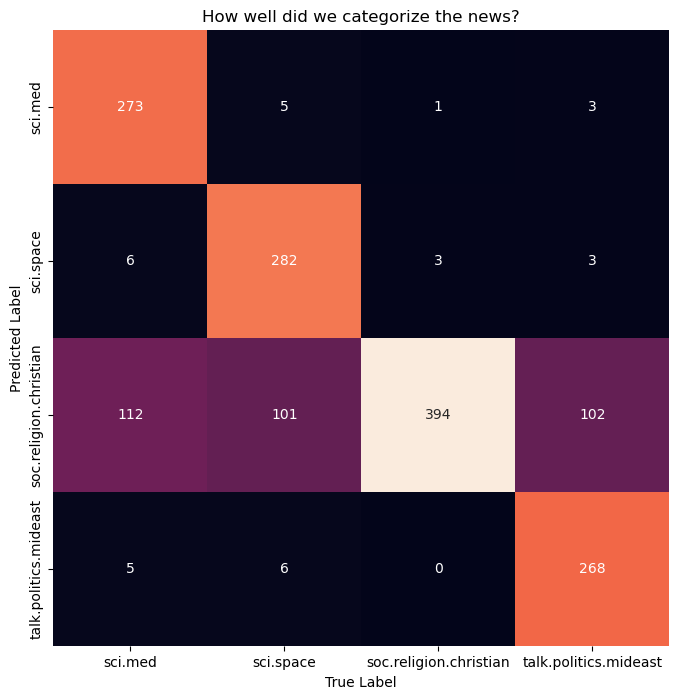

In [9]:
plt.figure(figsize=(10, 8))
mat = confusion_matrix(test.target, labels)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=train.target_names, yticklabels=train.target_names)
plt.xlabel('True Label')
plt.ylabel('Predicted Label')
plt.title('How well did we categorize the news?')
plt.show()

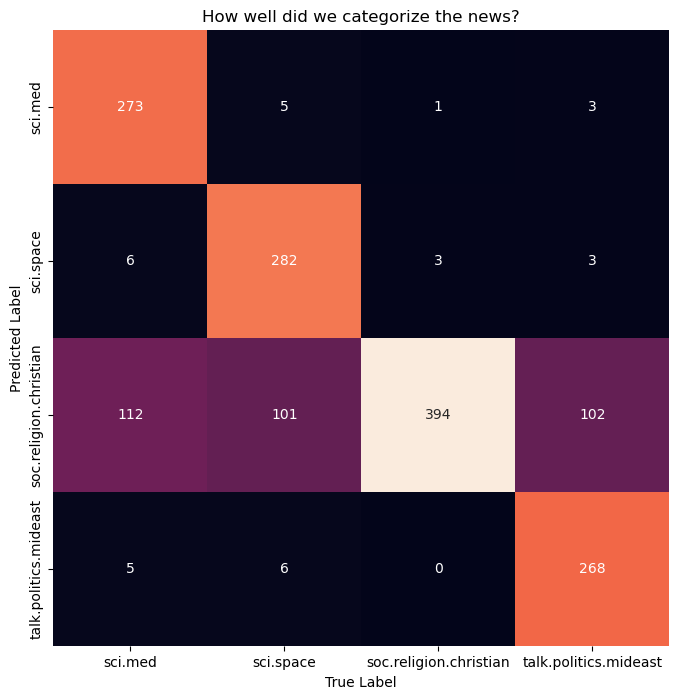

In [10]:
plt.figure(figsize=(10, 8))
mat = confusion_matrix(test.target, labels)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=train.target_names, yticklabels=train.target_names)
plt.xlabel('True Label')
plt.ylabel('Predicted Label')
plt.title('How well did we categorize the news?')
plt.show()